In [1]:
import numpy as np
import pandas as pd
from numpy import nan
from sklearn.preprocessing import  StandardScaler, OneHotEncoder, MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.datasets import make_classification 
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA, TruncatedSVD
from nltk.stem import SnowballStemmer
from sklearn import linear_model, datasets
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectKBest, SelectFpr, chi2, mutual_info_classif, f_classif
from sklearn.linear_model import SGDClassifier
from sklearn.metrics.pairwise import cosine_similarity
from nltk.stem import SnowballStemmer
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV

In [2]:
df = pd.read_csv('./winter_project_2026/development.csv')
eva = pd.read_csv('./winter_project_2026/evaluation.csv')
test_ids = eva.index

In [ ]:
df.shape, eva.shape

((79997, 7), (20000, 6))

In [12]:
pure_sources = [
    'Syfy.com', 'Topix', 'PCWorld', 'BCC', 'Computerworld', 
    'Register', 'Search', 'CNET', 'InfoWorld', 'IPS', 'Topix.Net',
    'Motley', 'Ananova', 'Forbes', 'Newsweek', 'News', 'CNN',
    'Sports', 'ESPN'
]

mask = df['source'].isin(pure_sources)
df[mask].count()

Id           10300
source       10300
title        10299
article      10299
page_rank    10300
timestamp    10300
label        10300
dtype: int64

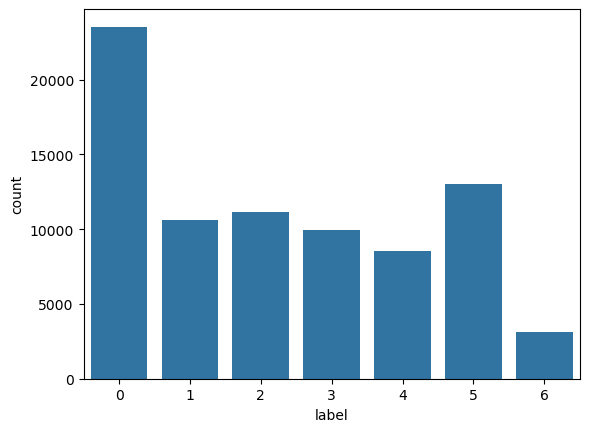

In [4]:
import seaborn as sns
sns.countplot(data=df, x='label')
plt.show()

In [188]:
dup_tit = df['title'].duplicated().sum()
dup_art = df['article'].duplicated().sum()
dup_art_tit = df[['article', 'title']].duplicated().sum()
dup_art_tit_src = df[['article', 'title', 'source']].duplicated().sum()
full = df.loc[:, 'source':'page_rank'].duplicated().sum()

mask = df[['article', 'title', 'source']].duplicated()
duplicated = df.groupby('label').count()['Id']

dup_art, dup_tit, dup_art_tit, dup_art_tit_src, full

(np.int64(5603),
 np.int64(4213),
 np.int64(2954),
 np.int64(2865),
 np.int64(2863))

In [189]:
df.drop_duplicates(inplace=True)

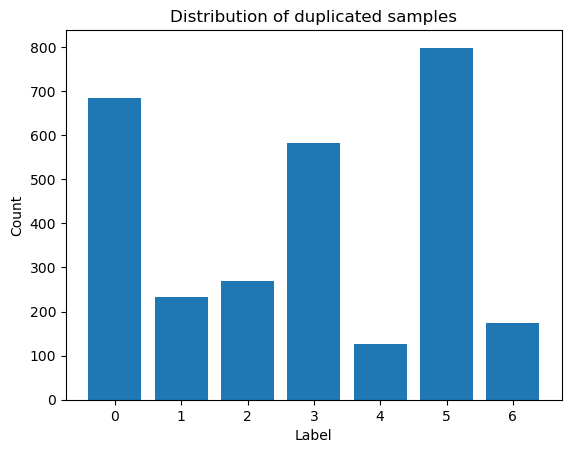

In [190]:
import matplotlib.pyplot as plt

# Raggruppa e conta le occorrenze
counts = df[mask].groupby('label').count()['Id']

# Plot dinamico
plt.bar(counts.index, counts.values)

plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Distribution of duplicated samples')
plt.xticks(counts.index)
plt.show()

In [191]:
df['article_word_count'] = df['article'].apply(lambda x: len(str(x).split()))
df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))
eva['article_word_count'] = eva['article'].apply(lambda x: len(str(x).split()))
eva['title_word_count'] = eva['title'].apply(lambda x: len(str(x).split()))

In [192]:
df.groupby('label')['article_word_count'].mean(), df.groupby('label')['title_word_count'].mean()

(label
 0    38.855492
 1    28.620797
 2    47.573515
 3    35.996592
 4    36.675764
 5    25.811691
 6    32.955190
 Name: article_word_count, dtype: float64,
 label
 0    7.274531
 1    6.759350
 2    7.327659
 3    7.146938
 4    6.675881
 5    6.425879
 6    7.248227
 Name: title_word_count, dtype: float64)

In [193]:
df.drop(['Id'], inplace=True, axis=1)
eva.drop(['Id'], inplace=True, axis=1)
df.columns

Index(['source', 'title', 'article', 'page_rank', 'timestamp', 'label',
       'article_word_count', 'title_word_count'],
      dtype='object')

In [194]:
import pandas as pd
import numpy as np

def extract_time_features(dataframe, col_name='timestamp'):
    df_temp = dataframe.copy()
    
    dates = pd.to_datetime(df_temp[col_name], errors='coerce')
    
    df_temp['day_of_week'] = dates.dt.dayofweek.fillna(-1).astype(int)
    
    hours = dates.dt.hour
    
    cond_morning   = (hours > 5) & (hours <= 14)
    cond_afternoon = (hours > 14) & (hours <= 21)
    cond_night     = (hours > 21) | (hours <= 5)
    
    conditions = [cond_morning, cond_afternoon, cond_night]
    choices    = [1, 2, 3] # 1: Morning, 2: Afternoon, 3: Night
    
    df_temp['moment_of_day'] = np.select(conditions, choices, default=-1)
    
    return df_temp

print("Elaborazione DF...")
df = extract_time_features(df)

print("Elaborazione EVA...")
eva = extract_time_features(eva)

# Check rapido
print(df[['timestamp', 'day_of_week', 'moment_of_day']].head())

Elaborazione DF...
Elaborazione EVA...
             timestamp  day_of_week  moment_of_day
0  2004-09-16 22:39:53            3              3
1  2004-12-17 19:01:14            4              2
2  2006-10-05 18:42:29            3              2
3  0000-00-00 00:00:00           -1             -1
4  2006-09-22 17:28:57            4              2


In [195]:
# Crea la tabella di frequenza
counts = pd.crosstab(df['label'], df['day_of_week'])
print(counts)

day_of_week    -1     0     1     2     3     4     5     6
label                                                      
0            8136  2161  2388  2464  2685  2349  1714  1645
1            3286  1061  1306  1231  1404  1345   581   374
2            2463  1171  1568  1584  1650  1514   742   469
3            4043   888   925   951  1018  1024   648   480
4            3728   686   634   665   764   751   633   713
5            4918  1200  1341  1184  1425  1240   834   911
6            1176   211   354   345   372   332   176   136


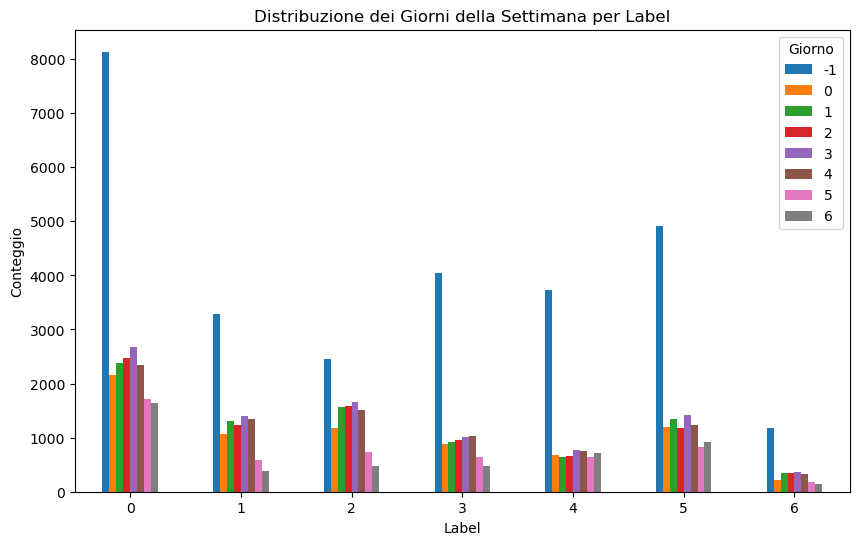

In [196]:
import matplotlib.pyplot as plt

# Genera un grafico a barre raggruppate
pd.crosstab(df['label'], df['day_of_week']).plot(kind='bar', figsize=(10, 6))

plt.title('Distribuzione dei Giorni della Settimana per Label')
plt.xlabel('Label')
plt.ylabel('Conteggio')
plt.legend(title='Giorno')
plt.xticks(rotation=0)
plt.show()

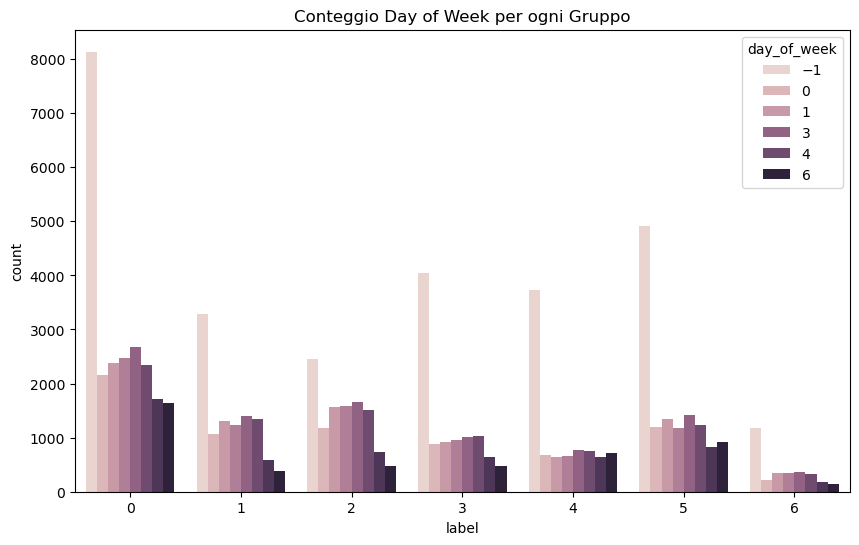

In [197]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='label', hue='day_of_week')
plt.title('Conteggio Day of Week per ogni Gruppo')
plt.show()

In [198]:
# Assicurati di aver installato lxml: pip install lxml
import pandas as pd
from bs4 import BeautifulSoup, Comment
import re

def clean_html_optimized(html_content):
    if not isinstance(html_content, str):
        return ""
    soup = BeautifulSoup(html_content, "lxml") 

    meta_desc = ""
    meta_tag = soup.find('meta', attrs={'name': 'description'})
    if meta_tag and 'content' in meta_tag.attrs:
        meta_desc = meta_tag['content']

    for tag in soup(['script', 'style', 'noscript', 'iframe', 'svg', 'header', 'footer', 'nav']):
        tag.decompose()

    comments = soup.find_all(string=lambda text: isinstance(text, Comment))
    for c in comments:
        c.extract()

    for img in soup.find_all('img'):
        if img.get('alt'):
            img.replace_with(f" {img['alt']} ") 

    text = soup.get_text(separator=' ', strip=True)
    final_text = f"{text} {meta_desc}"

    return WHITESPACE_HANDLER.sub(' ', final_text).strip()

WHITESPACE_HANDLER = re.compile(r'\s+')

df['article'] = df['article'].apply(clean_html_optimized)
df['title'] = df['title'].apply(clean_html_optimized)
eva['article'] = eva['article'].apply(clean_html_optimized)
eva['title'] = eva['title'].apply(clean_html_optimized)

/var/folders/j9/m1q0h7955ls67lg17_lw___80000gn/T/ipykernel_42663/1482464746.py:9: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a URL than HTML or XML.

If you meant to use Beautiful Soup to parse the web page found at a certain URL, then something has gone wrong. You should use an Python package like 'requests' to fetch the content behind the URL. Once you have the content as a string, you can feed that string into Beautiful Soup.

However, if you want to parse some data that happens to look like a URL, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  soup = BeautifulSoup(html_content, "lxml")


In [199]:
df['article_word_count'] = df['article'].apply(lambda x: len(str(x).split()))
df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))
eva['article_word_count'] = eva['article'].apply(lambda x: len(str(x).split()))
eva['title_word_count'] = eva['title'].apply(lambda x: len(str(x).split()))

df.drop('timestamp', axis=1, inplace=True)

========== NUMBER OF ARTICLES CONTAINING LESS THAN 1 WORDS ===========
label
0    22
1     8
2     6
3     1
4     2
5    71
6     1
Name: article, dtype: int64


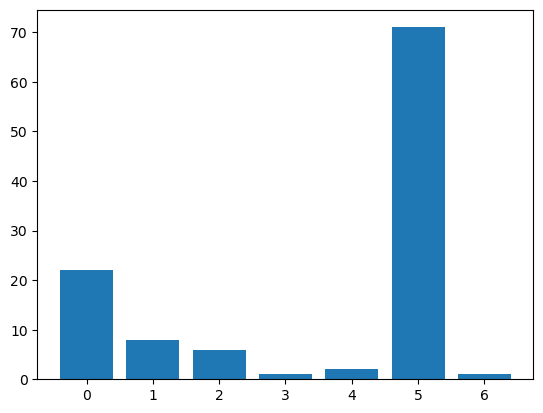

========== NUMBER OF ARTICLES CONTAINING LESS THAN 2 WORDS ===========
label
0      52
1     910
2      15
3      17
4       4
5    1023
6       1
Name: article, dtype: int64


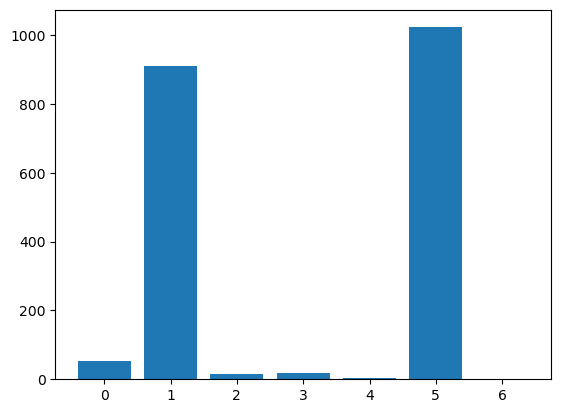

========== NUMBER OF ARTICLES CONTAINING LESS THAN 3 WORDS ===========
label
0      57
1     912
2      84
3      18
4       5
5    1198
6       1
Name: article, dtype: int64


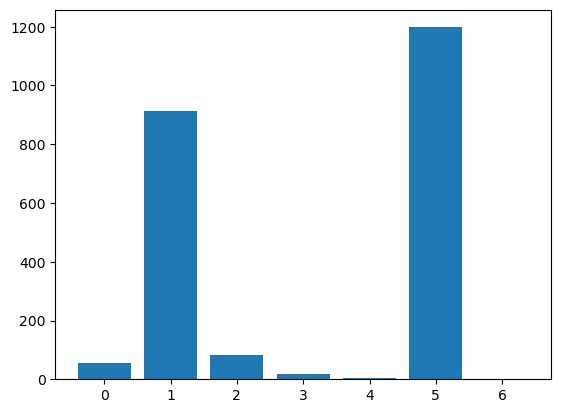

========== NUMBER OF ARTICLES CONTAINING LESS THAN 4 WORDS ===========
label
0      61
1     925
2     112
3      25
4       7
5    1242
6       1
Name: article, dtype: int64


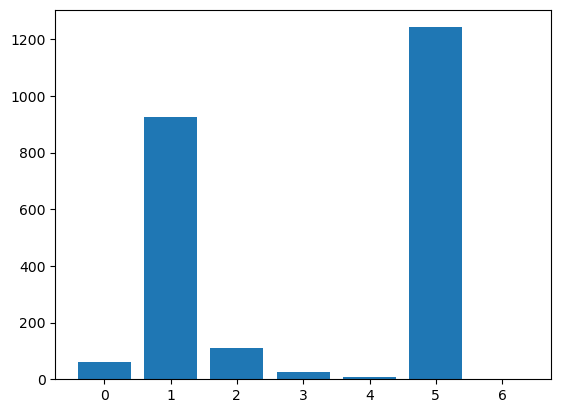

========== NUMBER OF ARTICLES CONTAINING LESS THAN 5 WORDS ===========
label
0      72
1     949
2     159
3      29
4      10
5    1280
6       1
Name: article, dtype: int64


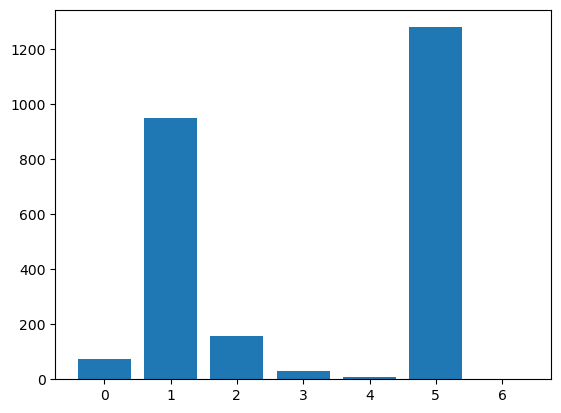

In [200]:
for i in range(1,6):
    short_texts = df[df['article_word_count']  < i]
    grouped = short_texts.groupby('label')
    print(f'========== NUMBER OF ARTICLES CONTAINING LESS THAN {i} WORDS ===========')
    print(grouped['article'].count())
    plot = plt.bar( grouped['article'].count().index, grouped['article'].count().values)
    plt.show()

In [201]:
min_words = 3
max_words = 100

short_texts = (df['article_word_count'] < min_words)
print(f"articles with less than {min_words} words: {df[short_texts]['article'].count()}")
print(df[short_texts].groupby('label')['article'].count())

#long_texts = (df['article_word_count'] > max_words)
#print(f'articles with more than {max_words} words: {df[long_texts]['article'].count()}')
#print(df[long_texts].groupby('label')['article'].count())

articles with less than 3 words: 2275
label
0      57
1     912
2      84
3      18
4       5
5    1198
6       1
Name: article, dtype: int64


In [202]:
print(df.groupby('label')['article_word_count'].mean())
print(df.groupby('label')['article_word_count'].std())
print(df.groupby('label')['article_word_count'].max())

label
0    37.269178
1    27.754345
2    44.755667
3    34.736293
4    35.717518
5    24.909216
6    32.456802
Name: article_word_count, dtype: float64
label
0    23.460432
1    16.674550
2    88.627127
3    21.096751
4    18.147406
5    11.999941
6    16.283938
Name: article_word_count, dtype: float64
label
0     403
1     184
2    1905
3     290
4     243
5      77
6     190
Name: article_word_count, dtype: int64


In [203]:
#df.drop(df[short_texts].index, inplace=True)
#df.drop(df[long_texts].index, inplace=True)

In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79997 entries, 0 to 79996
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   source              79997 non-null  object
 1   title               79997 non-null  object
 2   article             79997 non-null  object
 3   page_rank           79997 non-null  int64 
 4   label               79997 non-null  int64 
 5   article_word_count  79997 non-null  int64 
 6   title_word_count    79997 non-null  int64 
 7   day_of_week         79997 non-null  int64 
 8   moment_of_day       79997 non-null  int64 
dtypes: int64(6), object(3)
memory usage: 5.5+ MB


In [205]:
df['text'] = df['source'] + ' ' + df['source'] + ' ' + df['title'] + ' ' + df['title'] + ' ' + df['title'] + ' ' + df['article'] + ' ' + df['article']
eva['text'] = eva['source'] + ' ' + eva['source'] + ' ' + eva['title'] + ' ' + eva['title'] + ' ' + eva['title'] + ' ' + eva['article'] + ' ' + eva['article']

In [206]:
df['text']

0        AllAfrica.com AllAfrica.com OPEC Boosts Nigeri...
1        Xinhua Xinhua Yearender: Mideast peace roadmap...
2        Yahoo Yahoo Battleground Dispatches for Oct. 5...
3        BBC BBC Air best to resuscitate newborns Air b...
4        Yahoo Yahoo High tech German train crash kills...
                               ...                        
79992    Yahoo Yahoo Italy's embattled Prodi faces vote...
79993    All-Baseball.com All-Baseball.com Ding Dong, t...
79994    Yahoo Yahoo Two bombs discovered in Sardinia a...
79995    Voice Voice Red Cross Report Alleges US Detain...
79996    Yahoo Yahoo UN: Myanmar allows early visit by ...
Name: text, Length: 79997, dtype: object

In [207]:
stemmer = SnowballStemmer('english')
def stemming_tokenizer(text):
    # Separa le parole
    words = text.split()
    # Applica lo stemmer a ogni parola e riunisci
    # (È qui che avviene la magia: "running" -> "run")
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

#df['text'] = df['text'].apply(stemming_tokenizer)

In [208]:
y = df['label']
df.drop('label', inplace=True, axis=1)

In [209]:
#X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)

In [210]:
X_train = df
X_test = eva
y_train = y

In [211]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

def extract_discriminative_keywords(X_text_series, y_labels, top_n=20, max_overlap=0.1):
    """
    Estrae le parole chiave uniche per ogni classe.
    max_overlap: se una parola appare nella top list di più del 10% delle classi, viene scartata (è troppo generica).
    """
    print("Vettorizzazione per analisi feature...")
    # Usiamo un vettorizzatore temporaneo solo per questa analisi
    vect_ana = TfidfVectorizer(ngram_range=(1, 2), min_df=5, stop_words='english', max_features=30000)
    X_tfidf = vect_ana.fit_transform(X_text_series)
    feature_names = np.array(vect_ana.get_feature_names_out())
    
    unique_keywords = {}
    all_top_words = []
    
    # 1. Trova le top words per ogni classe
    temp_class_words = {}
    classes = np.unique(y_labels)
    
    for label in classes:
        row_indices = np.where(y_labels == label)[0]
        # Media dei pesi TFIDF per questa classe
        avg_weights = np.asarray(X_tfidf[row_indices].mean(axis=0)).ravel()
        # Prendi gli indici delle top_n parole
        top_indices = np.argsort(avg_weights)[::-1][:top_n]
        words = feature_names[top_indices]
        temp_class_words[label] = set(words)
        all_top_words.extend(words)
        
    # 2. Calcola frequenza globale delle "top words" per scartare quelle comuni
    from collections import Counter
    word_counts = Counter(all_top_words)
    
    # 3. Filtra: tieni solo parole che sono specifiche per QUELLA classe
    print("\n--- Parole Chiave Discriminanti Selezionate ---")
    for label in classes:
        specific_words = []
        for word in temp_class_words[label]:
            # Se la parola appare come "top" in troppe classi (es. > 2), scartala
            if word_counts[word] <= 1: 
                specific_words.append(word)
        
        unique_keywords[label] = list(specific_words)
        print(f"Label {label}: {specific_words[:8]}...") # Stampa anteprima
        
    return unique_keywords

# --- COME USARLO NEL TUO CODICE ---

# 1. Esegui l'analisi (fallo una volta sul train set)

# 2. Crea la funzione trasformatrice che usa questo dizionario
def count_all_class_keywords(text_series, lexicons_dict):
    # Restituisce una matrice con N colonne (una per classe)
    # Ogni colonna conta le parole chiave di quella classe trovate nel testo
    features = []
    for label, words in lexicons_dict.items():
        # Crea set per velocità
        word_set = set(words)
        # Conta
        col = text_series.apply(lambda x: sum(1 for w in x.lower().split() if w in word_set))
        features.append(col.values)
    
    return np.column_stack(features) # Matrice (n_samples, n_classes)

# NOTA: Per inserirlo nella pipeline, dovrai wrapparlo o salvarlo staticamente
# Per ora, lanciando la funzione sopra, otterrai la lista da copiare/incollare o usare dinamicamente.
lexicons_dict = extract_discriminative_keywords(X_train['text'], y_train, top_n=100, max_overlap=0)

Vettorizzazione per analisi feature...

--- Parole Chiave Discriminanti Selezionate ---
Label 0: ['russia', 'afp', 'topix net', 'darfur', 'topix', 'prime minister', 'party', 'foreign']...
Label 1: ['stock', 'buy', 'dollar', 'profits', 'international international', 'largest', 'economy', 'pay']...
Label 2: ['open source', 'mail', 'sun', 'space', 'cnet cnet', 'plans', 'search', 'launch']...
Label 3: ['cbs', 'box office', 'awards', 'syfy com', 'best', 'oscar', 'fashion', 'hit']...
Label 4: ['points', 'winning', '10', 'boston boston', 'athens', 'champion', 'soccer', 'career']...
Label 5: ['car', 'george', 'kills', 'read story', 'details', 'cnn', 'story latest', 'uk']...
Label 6: ['hospital', 'breast', 'drugs', 'vaccine', 'suggests', 'reuters health', 'health', 'breast cancer']...


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, FunctionTransformer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report

# ---------------------------------------------------------
# 1. SETUP & PULIZIA
# ---------------------------------------------------------

# Uniamo le stop words standard con quelle "spazzatura" che abbiamo trovato (boilerplate)
custom_trash = ['read', 'story', 'latest', 'details', 'loading', 'click', 'updated']
my_stop_words = list(ENGLISH_STOP_WORDS)

def extract_discriminative_keywords(X_text_series, y_labels, top_n=100, max_overlap=0):
    """
    Estrae le parole esclusive per ogni classe dal Training Set.
    Restituisce un dizionario: {label: {word1, word2, ...}}
    """
    print(">>> Estrazione feature discriminanti (Lexicons)...")
    
    # Vettorizzatore 'usa e getta' solo per l'analisi
    vect = TfidfVectorizer(ngram_range=(1, 2),
                           max_df=0.8,
                           stop_words=my_stop_words, 
                           max_features=30000)
    X_tfidf = vect.fit_transform(X_text_series)
    feats = np.array(vect.get_feature_names_out())
    
    lexicons = {}
    classes = np.unique(y_labels)
    
    # Calcoliamo le parole top per ogni classe
    candidate_words = {}
    all_candidates = []
    
    for label in classes:
        idx = np.where(y_labels == label)[0]
        # Media dei pesi per classe
        avg = np.asarray(X_tfidf[idx].mean(axis=0)).ravel()
        # Top N parole
        top_idx = np.argsort(avg)[::-1][:top_n]
        words = feats[top_idx]
        candidate_words[label] = set(words)
        all_candidates.extend(words)

    # Contiamo in quante classi appare ogni parola (per gestire l'overlap)
    from collections import Counter
    counts = Counter(all_candidates)
    
    # Salviamo solo le parole che appaiono in MAX 'max_overlap' classi (es. 0 o 1)
    for label in classes:
        clean_list = [w for w in candidate_words[label] if counts[w] <= (max_overlap + 1)]
        lexicons[label] = set(clean_list) # Usiamo set per velocità di ricerca O(1)
        print(f"Label {label}: {list(clean_list)[:8]}") # Debug
        print(len(list(clean_list)))
    return lexicons

# ---------------------------------------------------------
# 2. FUNZIONE TRASFORMATRICE (Il cuore della nuova feature)
# ---------------------------------------------------------

def lexicon_counter(text_series, lexicons_dict):
    """
    Input: Series di testo
    Output: Matrice (n_samples, n_classes) con i conteggi
    """
    # Ordiniamo le label per garantire che le colonne siano sempre nello stesso ordine (0, 1, 2...)
    sorted_labels = sorted(lexicons_dict.keys())
    
    # Pre-allocazione matrice risultati
    n_samples = len(text_series)
    n_features = len(sorted_labels)
    X_out = np.zeros((n_samples, n_features))
    
    # Conversione in lista per velocità
    texts = text_series.astype(str).str.lower().tolist()
    
    for i, text in enumerate(texts):
        tokens = set(text.split()) # Tokenizzazione semplice
        for j, label in enumerate(sorted_labels):
            keywords = lexicons_dict[label]
            # Conta quante keyword della classe J sono presenti nel testo I
            # L'intersezione tra set è velocissima
            X_out[i, j] = len(tokens.intersection(keywords))
            
    return X_out

# ---------------------------------------------------------
# 3. ESECUZIONE (Main Logic)
# ---------------------------------------------------------

# A. Generiamo il dizionario (SOLO SU TRAIN!)
# Assumiamo che tu abbia X_train e y_train disponibili
lexicons_map = extract_discriminative_keywords(X_train['text'], y_train, top_n=500, max_overlap=0.5)

# B. Definizione Pipeline Componenti

# Pipeline Testuale (TF-IDF Char n-grams)

text_char_pipe = Pipeline([
    ('vec', TfidfVectorizer(
        analyzer="char", 
        ngram_range=(3, 5), 
        min_df=10, 
        max_features=50000, 
        sublinear_tf=True
    )),
    ('svd', TruncatedSVD(
            n_components=1000, 
            algorithm='randomized'))
    #('selector2', SelectKBest(score_func=mutual_info_classif, k=15000))
    # Se vuoi usare SelectKBest qui, fallo pure
])


text_pipe = Pipeline([
    ('vec', TfidfVectorizer(
        ngram_range=(1,2), 
        max_df = 0.6,
        max_features=30000, 
        sublinear_tf=True
    )),
    ('svd', TruncatedSVD(
        n_components=1000, 
        algorithm='randomized'))
    #('selector2', SelectKBest(score_func=mutual_info_classif, k=10000))
    # Se vuoi usare SelectKBest qui, fallo pure
])


# Pipeline "Lexicon Counting" (Le nuove 7 colonne)
# Nota: Usiamo MinMaxScaler perché i conteggi possono essere 0, 5, 10. 
# Vogliamo portarli a 0-1 per non sbilanciare l'SGD.
lexicon_pipe = Pipeline([
    ('counter', FunctionTransformer(lexicon_counter, kw_args={'lexicons_dict': lexicons_map}, validate=False)),
    ('scaler', MinMaxScaler()) 
])

# C. Assemblaggio ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    
    # 1. Il testo classico (Caratteri per robustezza)
    ('text_char', text_char_pipe, 'text'),
    ('text_words', text_pipe, 'text'),
    
    # 2. LE TUE NUOVE FEATURE ESPERTE (7 colonne, una per classe)
        ('lexicons', lexicon_pipe, 'text'),

    # 3. Metadati numerici (scalati)
    #('meta_num', MinMaxScaler(), ['article_word_count', 'title_word_count']),
    ('meta_num', MinMaxScaler(), ['page_rank']),

    # 4. Metadati categorici
    ('meta_cat', OneHotEncoder(handle_unknown='ignore'), ['source', 'day_of_week', 'moment_of_day'])
    
], remainder='drop', n_jobs=-1)


clf_svm = SGDClassifier(
    loss='modified_huber', 
    penalty='l2', 
    alpha=1e-4, 
    random_state=42, 
    max_iter=1000, 
    tol=1e-3,
    class_weight='balanced',
    n_jobs=-1           # Anche lui può usare tutto quando tocca a lui
)


# D. Pipeline Finale e Training
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', clf_svm)
])

print("Training modello ibrido (TF-IDF + Lexicon Features)...")
full_pipeline.fit(X_train, y_train)

print("Evaluation...")
y_pred = full_pipeline.predict(X_test)
#print(classification_report(y_test, y_pred))

submission = pd.DataFrame({
    'Id': test_ids,    # Usiamo gli ID salvati all'inizio
    'Predicted': y_pred # O 'label' o 'Category' a seconda delle regole della gara
})

submission.to_csv('submission_html_pp.csv', index=False)
print("Fatto! File pronto.")

>>> Estrazione feature discriminanti (Lexicons)...
Label 0: ['net topix', 'middle', 'region', 'suspect', 'islamic', 'rebel', 'spanish', 'indonesia']
74
Label 1: ['euro', 'expectations', 'pilots', 'corp said', 'rises', 'ft com', 'equity', 'profit rises']
197
Label 2: ['land', 'speed', 'web site', 'mail', 'sun', 'launches', 'download', 'aims']
200
Label 3: ['award', 'list', 'wife', 'producers', 'host', 'rapper', 'theater', 'hollywood reporter']
108
Label 4: ['points', 'olympics', 'jays', 'phillies', 'ncaa', 'ranked', '21', 'champion']
285
Label 5: ['baghdad reuters', 'falluja', 'killer', 'bhutto', 'foxnews', 'cia', 'cabinet', 'spy']
49
Label 6: ['linked', 'promise', 'health organization', 'weight', 'effects', 'suggests', 'prostate cancer', 'cold']
264
Training modello ibrido (TF-IDF + Lexicon Features)...
Evaluation...
Fatto! File pronto.


In [213]:
stop_words = list(ENGLISH_STOP_WORDS)


encoder = OneHotEncoder(min_frequency=20, handle_unknown='infrequent_if_exist')

scaler = MinMaxScaler()

text_pipeline_selector = Pipeline([
    ('vect', TfidfVectorizer(
        analyzer="char",
        ngram_range=(3,5),
        stop_words=stop_words,
        max_df = 0.8,
        max_features = 20000,
    )),
])
    #('selector2', SelectKBest(score_func=mutual_info_classif, k=1000))
    #('selector', SelectFpr(score_func=chi2, alpha=0.001)),
    #('selector2', SelectFpr(score_func=f_classif, alpha=0.001))

vectorizer = TfidfVectorizer(
        max_features=30000,
        stop_words='english',
        min_df=3)

vectorizer_title = TfidfVectorizer(
        max_features=3000,
        stop_words=stop_words,
        ngram_range=(1, 2),
        min_df=3)


preprocessor = ColumnTransformer(transformers=[
    ('text', text_pipeline_selector, 'text'),
    ('numerical', scaler, ['article_word_count', 'title_word_count']),
    ('source', encoder, ['source', 'day_of_week', 'moment_of_day'])
], remainder='drop',n_jobs=-1)
    
preprocessor_article_only = ColumnTransformer(transformers=[
    ('day_of_week', scaler, ['day_of_week', 'moment_of_day', 'article_word_count', 'title_word_count'])], remainder='drop')


In [214]:
X_train_final = preprocessor.fit_transform(X_train, y_train)
X_test_final = preprocessor.transform(X_test)

/opt/homebrew/Caskroom/miniconda/base/envs/dsml/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:539: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(


In [215]:
X_train_final, X_test_final

(<Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 39404376 stored elements and shape (79997, 20201)>,
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 9883428 stored elements and shape (20000, 20201)>)

In [216]:
X_train_final.shape

(79997, 20201)

In [217]:
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import confusion_matrix

weights = compute_sample_weight(class_weight='balanced', y=y_train)


clf = LogisticRegression(
    C=1,                       
    class_weight='balanced',    
    solver='liblinear',        
    penalty='l2',           
    max_iter=1000,              
    random_state=42
)
clf2 = RandomForestClassifier(
    random_state= 42,
    n_estimators=1500,
    max_depth=10,
    class_weight='balanced',
    n_jobs = -1
)

clf3 = GradientBoostingClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    random_state=42,
    warm_start=True,
)

svm = LinearSVC(C=1,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
)


clf5 = XGBClassifier(
        n_estimators=1000,      
        learning_rate=0.05,     
        max_depth=6,             
        min_child_weight=1,
        gamma=0.1,           
        subsample=0.8,           
        colsample_bytree=0.8,     
        n_jobs=-1,               
        random_state=42,
        eval_metric='mlogloss'  
    )

clf_svm = SGDClassifier(
    loss='modified_huber', 
    penalty='l2', 
    alpha=1e-4, 
    random_state=42, 
    max_iter=1000, 
    tol=1e-3,
    class_weight='balanced',
    n_jobs=-1           # Anche lui può usare tutto quando tocca a lui
)

clf_svm_prob = CalibratedClassifierCV(svm, method='sigmoid')
clf_nb = MultinomialNB()

voting_clf = VotingClassifier(
    estimators=[ 
        ('svm', clf_svm_prob), 
        ('xgb', clf5)
    ],
    voting='soft', weights=[2,1], verbose=True  # <--- Maggioranza secca
)


clf5.fit(X_train_final, y_train)
y_pred = clf5.predict(X_test_final)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


ValueError: Found input variables with inconsistent numbers of samples: [16000, 20000]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix_fatta_bene(y_true, y_pred, labels):
    """
    y_true: lista delle etichette reali
    y_pred: lista delle etichette predette dal modello
    labels: lista dei nomi delle classi (es. ['Sport', 'Politica', 'Esteri'])
    """

    # 1. Calcolo della matrice NORMALIZZATA
    # normalize='true' fa sì che la somma di ogni RIGA sia 1 (100%).
    # Questo ti dice: "Della classe X, quanti ne ho indovinati?"
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')

    # 2. Setup del grafico
    plt.figure(figsize=(10, 8)) # Dimensioni generose

    # 3. Disegno con Seaborn
    # annot=True: scrive i numeri nelle celle
    # fmt='.1%': formatta come percentuale con 1 decimale (es. 85.4%)
    # cmap='Blues': scala di blu (più scuro = più alto), ottima per report
    sns.heatmap(cm, 
                annot=True, 
                fmt='.1%', 
                xticklabels=labels, 
                yticklabels=labels, 
                cmap='Blues',
                cbar_kws={'label': 'Proporzione di predizioni'})

    # 4. Etichette assi (Cruciale per non confondersi)
    plt.ylabel('Realtà (True Label)', fontsize=12, fontweight='bold')
    plt.xlabel('Predizione (Predicted Label)', fontsize=12, fontweight='bold')
    plt.title('Confusion Matrix Normalizzata', fontsize=14)
    
    plt.tight_layout()
    plt.show()

# Esempio di utilizzo fittizio
# labels_list = ['Sport', 'Politica', 'Cronaca']
# plot_confusion_matrix_fatta_bene(y_test, predictions, labels_list)


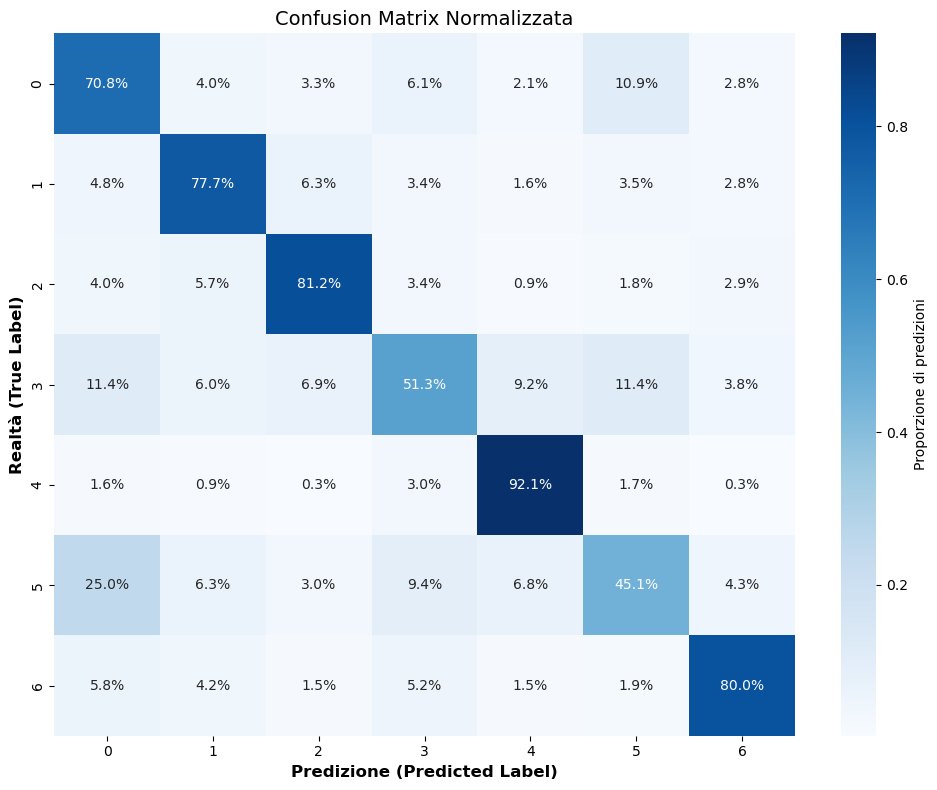

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix_fatta_bene(y_true, y_pred, labels):
    """
    y_true: lista delle etichette reali
    y_pred: lista delle etichette predette dal modello
    labels: lista dei nomi delle classi (es. ['Sport', 'Politica', 'Esteri'])
    """

    # 1. Calcolo della matrice NORMALIZZATA
    # normalize='true' fa sì che la somma di ogni RIGA sia 1 (100%).
    # Questo ti dice: "Della classe X, quanti ne ho indovinati?"
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')

    # 2. Setup del grafico
    plt.figure(figsize=(10, 8)) # Dimensioni generose

    # 3. Disegno con Seaborn
    # annot=True: scrive i numeri nelle celle
    # fmt='.1%': formatta come percentuale con 1 decimale (es. 85.4%)
    # cmap='Blues': scala di blu (più scuro = più alto), ottima per report
    sns.heatmap(cm, 
                annot=True, 
                fmt='.1%', 
                xticklabels=labels, 
                yticklabels=labels, 
                cmap='Blues',
                cbar_kws={'label': 'Proporzione di predizioni'})

    # 4. Etichette assi (Cruciale per non confondersi)
    plt.ylabel('Realtà (True Label)', fontsize=12, fontweight='bold')
    plt.xlabel('Predizione (Predicted Label)', fontsize=12, fontweight='bold')
    plt.title('Confusion Matrix Normalizzata', fontsize=14)
    
    plt.tight_layout()
    plt.show()

# Esempio di utilizzo fittizio
# labels_list = ['Sport', 'Politica', 'Cronaca']
# plot_confusion_matrix_fatta_bene(y_test, predictions, labels_list)

plot_confusion_matrix_fatta_bene(y_test, y_pred, labels=sorted(y_test.unique()))